In [1]:
import os
import re
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def parse_odometry_log(
    path: str,
    use_header_time: bool = True,
    default_rate_hz: float = 50.0,
) -> pd.DataFrame:
    """
    Parse a gz echo-style Odometry log into a DataFrame with columns:
      t, frame_id, child_frame_id,
      px, py, pz, qx, qy, qz, qw,
      vx, vy, vz, wx, wy, wz
    Time t is zeroed to the first sample if header stamps (sec/nsec) are found.
    Otherwise it is synthesized using default_rate_hz.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    # Structural patterns
    p_header_open = re.compile(r"^\s*header\s*\{")
    p_stamp_open = re.compile(r"^\s*stamp\s*\{")
    p_data_open = re.compile(r"^\s*data\s*\{")
    p_key = re.compile(r'^\s*key:\s*"([^"]+)"')
    p_val_str = re.compile(r'^\s*value:\s*"([^"]+)"')
    p_sec = re.compile(r"^\s*sec:\s*(-?\d+)")
    p_nsec = re.compile(r"^\s*nsec:\s*(\d+)")
    p_close = re.compile(r"^\s*\}")

    # Pose / twist blocks
    p_pose_open = re.compile(r"^\s*pose\s*\{")
    p_pos_open = re.compile(r"^\s*position\s*\{")
    p_ori_open = re.compile(r"^\s*orientation\s*\{")
    p_twist_open = re.compile(r"^\s*twist\s*\{")
    p_lin_open = re.compile(r"^\s*linear\s*\{")
    p_ang_open = re.compile(r"^\s*angular\s*\{")

    # Numeric components
    p_x = re.compile(r"^\s*x:\s*([-+0-9.eE]+)")
    p_y = re.compile(r"^\s*y:\s*([-+0-9.eE]+)")
    p_z = re.compile(r"^\s*z:\s*([-+0-9.eE]+)")
    p_w = re.compile(r"^\s*w:\s*([-+0-9.eE]+)")

    def fval(s: str) -> float:
        try:
            return float(s)
        except Exception:
            return np.nan

    rows: List[Dict[str, float]] = []

    cur: Dict[str, float] = {}
    cur_frame: Optional[str] = None
    cur_child: Optional[str] = None
    cur_sec: Optional[int] = None
    cur_nsec: Optional[int] = None

    # Block state
    in_stamp = False
    in_data = False
    data_key: Optional[str] = None
    in_mode: Optional[str] = None  # 'pos' | 'ori' | 'lin' | 'ang' | None

    def finalize():
        nonlocal cur, cur_frame, cur_child, cur_sec, cur_nsec
        if not cur and (cur_frame is None and cur_child is None):
            return
        cur["frame_id"] = cur_frame
        cur["child_frame_id"] = cur_child
        if use_header_time and (cur_sec is not None) and (cur_nsec is not None):
            cur["t_abs"] = float(cur_sec) + float(cur_nsec) * 1e-9
        else:
            cur["t_abs"] = np.nan
        rows.append(cur)
        cur = {}
        cur_frame = None
        cur_child = None
        cur_sec = None
        cur_nsec = None

    with open(path, "r") as f:
        for line in f:
            # Start of a new message
            if p_header_open.search(line):
                finalize()
                in_stamp = False
                in_data = False
                data_key = None
                in_mode = None
                continue

            # header.stamp
            if p_stamp_open.search(line):
                in_stamp = True
                continue
            if in_stamp:
                ms = p_sec.search(line)
                if ms:
                    cur_sec = int(ms.group(1))
                    continue
                mn = p_nsec.search(line)
                if mn:
                    cur_nsec = int(mn.group(1))
                    continue
                if p_close.search(line):
                    in_stamp = False
                    continue

            # header.data { key: "...", value: "..." }
            if p_data_open.search(line):
                in_data = True
                data_key = None
                continue
            if in_data:
                mk = p_key.search(line)
                if mk:
                    data_key = mk.group(1)
                    continue
                mv = p_val_str.search(line)
                if mv and data_key:
                    if data_key == "frame_id":
                        cur_frame = mv.group(1)
                    elif data_key == "child_frame_id":
                        cur_child = mv.group(1)
                    continue
                if p_close.search(line):
                    in_data = False
                    data_key = None
                    continue

            # Pose / Twist sub-blocks
            if p_pos_open.search(line):
                in_mode = "pos"
                continue
            if p_ori_open.search(line):
                in_mode = "ori"
                continue
            if p_lin_open.search(line):
                in_mode = "lin"
                continue
            if p_ang_open.search(line):
                in_mode = "ang"
                continue

            # Close any of the sub-blocks
            if p_close.search(line) and in_mode is not None:
                in_mode = None
                continue

            # Numeric extraction based on block
            if in_mode is not None:
                mx = p_x.search(line)
                my = p_y.search(line)
                mz = p_z.search(line)
                mw = p_w.search(line)
                if in_mode == "pos":
                    if mx: cur["px"] = fval(mx.group(1))
                    if my: cur["py"] = fval(my.group(1))
                    if mz: cur["pz"] = fval(mz.group(1))
                elif in_mode == "ori":
                    if mx: cur["qx"] = fval(mx.group(1))
                    if my: cur["qy"] = fval(my.group(1))
                    if mz: cur["qz"] = fval(mz.group(1))
                    if mw: cur["qw"] = fval(mw.group(1))
                elif in_mode == "lin":
                    if mx: cur["vx"] = fval(mx.group(1))
                    if my: cur["vy"] = fval(my.group(1))
                    if mz: cur["vz"] = fval(mz.group(1))
                elif in_mode == "ang":
                    if mx: cur["wx"] = fval(mx.group(1))
                    if my: cur["wy"] = fval(my.group(1))
                    if mz: cur["wz"] = fval(mz.group(1))

    # finalize last
    finalize()

    if not rows:
        raise RuntimeError("No Odometry messages parsed from log")

    df = pd.DataFrame(rows)

    # Time vector
    if use_header_time and np.isfinite(df.get("t_abs", np.nan)).any():
        t0 = df["t_abs"].min(skipna=True)
        df["t"] = df["t_abs"] - t0
    else:
        n = len(df)
        dt = 1.0 / float(default_rate_hz if default_rate_hz > 0 else 50.0)
        df["t"] = np.arange(n, dtype=float) * dt

    # Ensure complete schema
    for c in ("px","py","pz","qx","qy","qz","qw","vx","vy","vz","wx","wy","wz","frame_id","child_frame_id"):
        if c not in df.columns:
            df[c] = np.nan

    # Derived quantities
    qx = df["qx"].fillna(0.0).to_numpy()
    qy = df["qy"].fillna(0.0).to_numpy()
    qz = df["qz"].fillna(0.0).to_numpy()
    qw = df["qw"].fillna(1.0).to_numpy()
    # yaw from quaternion (ZYX), robust to missing qx,qy (assumed 0)
    yaw = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy*qy + qz*qz))
    df["yaw"] = yaw

    vx = df["vx"].fillna(0.0).to_numpy()
    vy = df["vy"].fillna(0.0).to_numpy()
    vz = df["vz"].fillna(0.0).to_numpy()
    df["speed"] = np.sqrt(vx*vx + vy*vy + vz*vz)

    # Canonical column order
    cols = ["t","frame_id","child_frame_id",
            "px","py","pz","qx","qy","qz","qw",
            "vx","vy","vz","wx","wy","wz","yaw","speed"]
    return df[cols]


def plot_odometry_grid_4x2(df: pd.DataFrame, title: str = "", sharex: bool = True):
    """
    4x2 grid:
      r1: pose.x, pose.y
      r2: ori.z, ori.w
      r3: twist.linear.x, twist.angular.z
      r4: yaw (rad), speed (m/s)
    """
    if df.empty:
        print("Empty DataFrame")
        return

    fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=sharex, constrained_layout=True)
    t = df["t"].values

    series = [
        ("px", "pose.x [m]"), ("py", "pose.y [m]"),
        ("qz", "orientation.z"), ("qw", "orientation.w"),
        ("vx", "twist.linear.x [m/s]"), ("wz", "twist.angular.z [rad/s]"),
        ("yaw", "yaw [rad]"), ("speed", "speed [m/s]"),
    ]

    for k, (col, lab) in enumerate(series):
        i, j = divmod(k, 2)
        ax = axes[i, j]
        y = df[col].values if col in df.columns else np.full_like(t, np.nan)
        ax.plot(t, y, lw=1.2)
        ax.set_title(lab)
        ax.grid(True, alpha=0.3)

    # Labels
    for i in range(4):
        axes[i, 0].set_ylabel("value")
    axes[3, 0].set_xlabel("time [s]")
    axes[3, 1].set_xlabel("time [s]")

    if not title:
        ent = (df.get("frame_id").iloc[0] or "") if "frame_id" in df.columns and len(df) else ""
        tspan = (df["t"].min(), df["t"].max())
        title = f"{ent}  t=[{tspan[0]:.2f}, {tspan[1]:.2f}] s"

    fig.suptitle(title)
    plt.show()


def parse_and_plot_odom(
    path: str,
    use_header_time: bool = True,
    default_rate_hz: float = 50.0,
    seconds: Optional[float] = None,  # None => full dataset
):
    df = parse_odometry_log(path, use_header_time=use_header_time, default_rate_hz=default_rate_hz)
    if seconds is not None:
        # optional trimming if ever needed
        tmax = df["t"].max()
        tmin = max(0.0, tmax - float(seconds))
        df = df[df["t"] >= tmin].copy().reset_index(drop=True)
        title_suffix = f" (last {seconds:g} s)"
    else:
        title_suffix = " (full)"
    plot_odometry_grid_4x2(df, title=os.path.basename(path) + title_suffix)

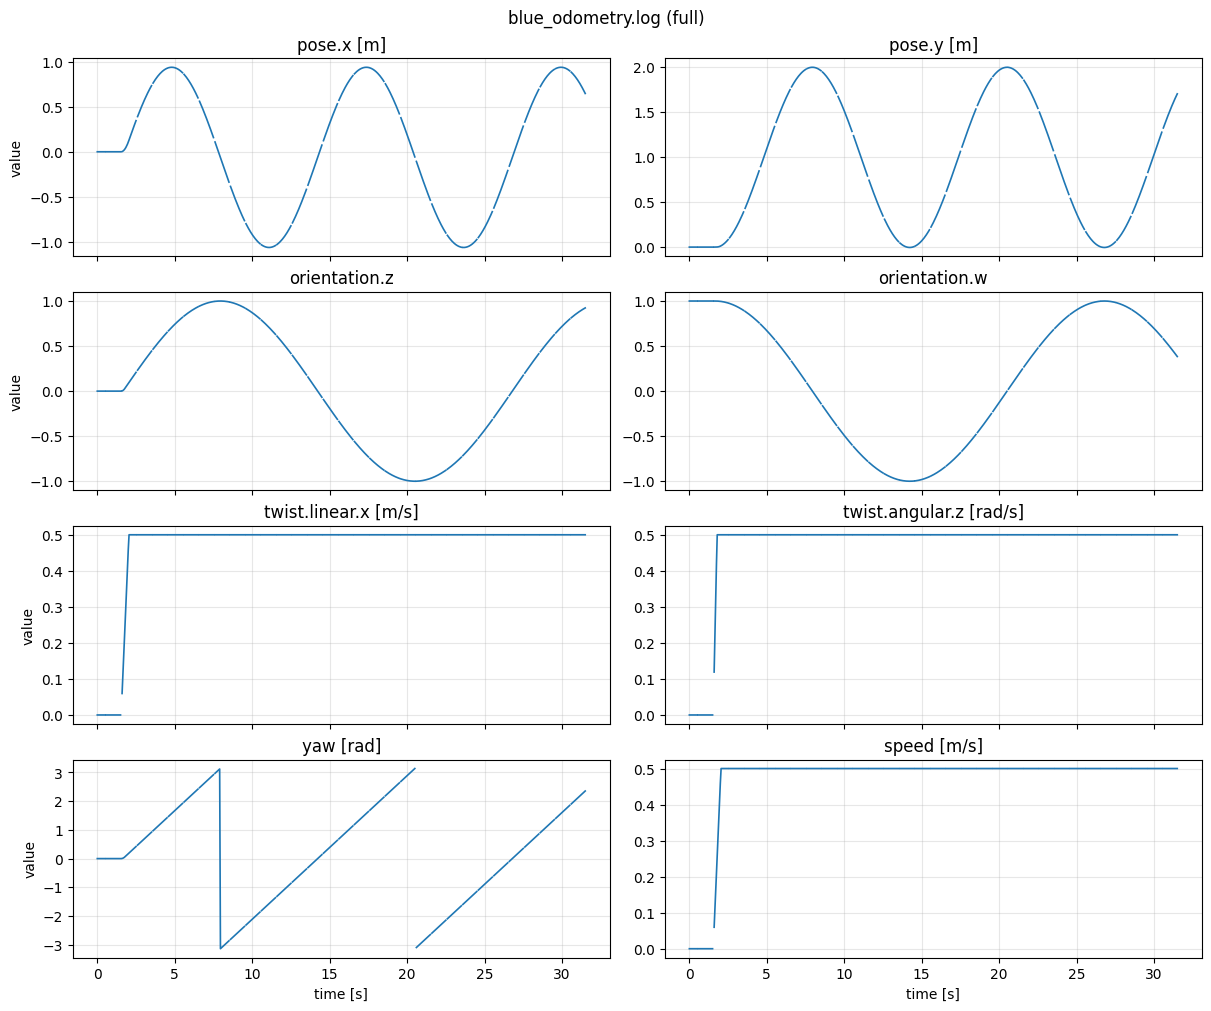

In [4]:
# Cell 1: run plot for your odometry echo log (full dataset)

log_path = "/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/blue_odometry.log"  # <-- set your file
parse_and_plot_odom(
    path=log_path,
    use_header_time=True,     # set False if your log lacks sec/nsec
    default_rate_hz=50.0,
    seconds=None,             # None => plot all samples
)